In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

tsla = pd.read_csv('data/TSLA_features.csv', parse_dates=['date'], index_col='date').sort_index()
tsla.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,-0.013938,-0.013273,14.863905,14.497746,...,0.005838,1,1,0,Winter,0,17.790001,0,0,-0.057681
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,-0.077825,14.760286,14.436762,...,0.025016,1,1,0,Winter,0,19.920000,0,1,-0.037508
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,-0.063932,14.655714,14.382794,...,-0.009262,1,1,0,Winter,0,21.120001,0,0,-0.033273
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,-0.050758,14.495047,14.342286,...,-0.015418,1,1,0,Winter,0,19.309999,0,0,-0.086561
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,-0.053010,14.351333,14.330413,...,0.000810,1,1,0,Winter,0,17.010000,0,0,-0.089023


In [2]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'vix'
]
TARGET_CLS = 'target_direction'

In [3]:
tsla_cls = tsla[FEATURES + [TARGET_CLS]].dropna().copy()
print(tsla_cls.shape)

(2515, 17)


In [4]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window + embargo,
                               start + train_window + embargo + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits

tsla_folds = walk_forward_splits(tsla_cls, train_window=59)
print("TSLA folds:", len(tsla_folds))

TSLA folds: 58


In [5]:
neg = (tsla_cls[TARGET_CLS] == 0).sum()
pos = (tsla_cls[TARGET_CLS] == 1).sum()
scale_pos_weight = neg / pos
print(f'DOWN: {neg}, UP: {pos}, scale_pos_weight: {scale_pos_weight:.3f}')

DOWN: 1212, UP: 1303, scale_pos_weight: 0.930


In [6]:
fold_scores = []
tsla_actual, tsla_pred = [], []
feat_imp_list = []

for train_idx, test_idx in tsla_folds:
    X_train = tsla_cls.iloc[train_idx][FEATURES]
    y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
    X_test  = tsla_cls.iloc[test_idx][FEATURES]
    y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_p = xgb.predict(X_test)

    feat_imp_list.append(xgb.feature_importances_)

    cm = confusion_matrix(y_test, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fold_scores.append({
        'accuracy':    accuracy_score(y_test, y_p),
        'f1':          f1_score(y_test, y_p, zero_division=0),
        'precision':   precision_score(y_test, y_p, zero_division=0),
        'recall':      recall_score(y_test, y_p, zero_division=0),
        'specificity': spec
    })
    tsla_actual.extend(y_test)
    tsla_pred.extend(y_p)

results_df = pd.DataFrame(fold_scores)
print(classification_report(tsla_actual, tsla_pred, zero_division=0))
print(results_df.describe())

              precision    recall  f1-score   support

           0       0.47      0.48      0.48      1170
           1       0.51      0.50      0.51      1266

    accuracy                           0.49      2436
   macro avg       0.49      0.49      0.49      2436
weighted avg       0.49      0.49      0.49      2436

        accuracy         f1  precision     recall  specificity
count  58.000000  58.000000  58.000000  58.000000    58.000000
mean    0.491379   0.483674   0.520768   0.507359     0.490517
std     0.085637   0.140905   0.122950   0.222701     0.217199
min     0.333333   0.193548   0.294118   0.125000     0.045455
25%     0.428571   0.379022   0.416405   0.348370     0.333333
50%     0.488095   0.476190   0.529825   0.474937     0.466063
75%     0.547619   0.614600   0.611538   0.710714     0.683612
max     0.666667   0.724138   0.800000   1.000000     0.947368


bb_position       0.055140
ma_cross          0.056011
lag_return_1      0.058631
daily_return      0.060436
volatility_7      0.060755
weekly_return     0.061159
lag_return_5      0.061232
volatility_20     0.062237
vix               0.062476
volume_ratio      0.063453
lag_return_3      0.063485
macd_hist         0.064315
daily_range       0.064827
volume_change     0.065774
dist_from_ma21    0.069011
rsi_14            0.071058


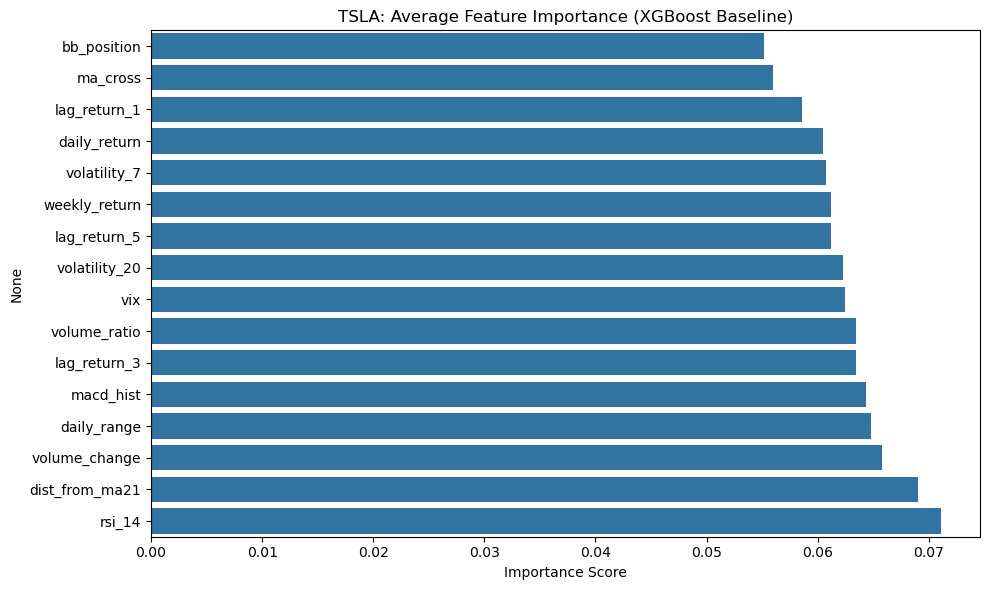

In [7]:
feat_imp = pd.DataFrame(feat_imp_list, columns=FEATURES).mean().sort_values()
print(feat_imp.to_string())

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('TSLA: Average Feature Importance (XGBoost Baseline)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [8]:
from itertools import product

n_estimators_values  = [100, 200, 500]
max_depth_values     = [3, 4, 6]
learning_rate_values = [0.01, 0.05, 0.1]
subsample_values     = [0.7, 0.8, 1.0]

combos = list(product(n_estimators_values, max_depth_values, learning_rate_values, subsample_values))
print(f'Grid: {len(n_estimators_values)} n_est x {len(max_depth_values)} depth x {len(learning_rate_values)} lr x {len(subsample_values)} subsample = {len(combos)} combinations')
print(f'Folds per combo: {len(tsla_folds)}')
print(f'Total XGB fits: {len(combos) * len(tsla_folds)}')

grid_results = []

for n_est, max_d, lr, subs in combos:
    fold_f1s, fold_accs, fold_precs, fold_recs, fold_specs = [], [], [], [], []

    for train_idx, test_idx in tsla_folds:
        X_train = tsla_cls.iloc[train_idx][FEATURES]
        y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
        X_test  = tsla_cls.iloc[test_idx][FEATURES]
        y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

        xgb = XGBClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subs,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        xgb.fit(X_train, y_train)
        y_p = xgb.predict(X_test)

        fold_f1s.append(f1_score(y_test, y_p, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_p))
        fold_precs.append(precision_score(y_test, y_p, zero_division=0))
        fold_recs.append(recall_score(y_test, y_p, zero_division=0))

        cm = confusion_matrix(y_test, y_p, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    grid_results.append({
        'n_estimators':  n_est,
        'max_depth':     max_d,
        'learning_rate': lr,
        'subsample':     subs,
        'f1':          np.mean(fold_f1s),
        'accuracy':    np.mean(fold_accs),
        'precision':   np.mean(fold_precs),
        'recall':      np.mean(fold_recs),
        'specificity': np.mean(fold_specs),
    })
    print(f'  n_est={n_est:>3}  depth={max_d}  lr={lr:.2f}  subs={subs:.1f}  '
          f'F1={np.mean(fold_f1s):.3f}  acc={np.mean(fold_accs):.3f}  '
          f'prec={np.mean(fold_precs):.3f}  rec={np.mean(fold_recs):.3f}  spec={np.mean(fold_specs):.3f}')

xgb_grid_df = pd.DataFrame(grid_results)

Grid: 3 n_est x 3 depth x 3 lr x 3 subsample = 81 combinations
Folds per combo: 58
Total XGB fits: 4698
  n_est=100  depth=3  lr=0.01  subs=0.7  F1=0.459  acc=0.493  prec=0.515  rec=0.507  spec=0.494
  n_est=100  depth=3  lr=0.01  subs=0.8  F1=0.454  acc=0.486  prec=0.496  rec=0.493  spec=0.495
  n_est=100  depth=3  lr=0.01  subs=1.0  F1=0.481  acc=0.507  prec=0.532  rec=0.507  spec=0.520
  n_est=100  depth=3  lr=0.05  subs=0.7  F1=0.475  acc=0.487  prec=0.517  rec=0.501  spec=0.488
  n_est=100  depth=3  lr=0.05  subs=0.8  F1=0.484  acc=0.494  prec=0.526  rec=0.509  spec=0.496
  n_est=100  depth=3  lr=0.05  subs=1.0  F1=0.478  acc=0.493  prec=0.523  rec=0.495  spec=0.508
  n_est=100  depth=3  lr=0.10  subs=0.7  F1=0.483  acc=0.491  prec=0.522  rec=0.509  spec=0.489
  n_est=100  depth=3  lr=0.10  subs=0.8  F1=0.489  acc=0.498  prec=0.529  rec=0.512  spec=0.501
  n_est=100  depth=3  lr=0.10  subs=1.0  F1=0.484  acc=0.498  prec=0.528  rec=0.500  spec=0.513
  n_est=100  depth=4  lr=0.01  s

In [9]:
print('Top 5 by F1:')
print(xgb_grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('\nTop 5 by Accuracy:')
print(xgb_grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('\nTop 5 by Precision:')
print(xgb_grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('\nTop 5 by Specificity:')
print(xgb_grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nBaseline (n_est=100, depth=4, lr=0.1, subs=0.8):')
baseline = xgb_grid_df[
    (xgb_grid_df['n_estimators'] == 100) &
    (xgb_grid_df['max_depth'] == 4) &
    (xgb_grid_df['learning_rate'] == 0.1) &
    (xgb_grid_df['subsample'] == 0.8)
]
print(baseline.to_string(index=False))

Top 5 by F1:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          500          3            0.1        1.0 0.502213  0.502053   0.536592 0.523503     0.499488
          500          6            0.1        0.8 0.495918  0.495895   0.520669 0.527197     0.478911
          500          4            0.1        1.0 0.493110  0.496305   0.526158 0.516669     0.494767
          200          3            0.1        1.0 0.492857  0.499179   0.533003 0.509068     0.507148
          500          3            0.1        0.8 0.492734  0.490969   0.522052 0.520913     0.477973

Top 5 by Accuracy:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          100          3           0.01        1.0 0.481489  0.507389   0.532491 0.506900     0.519655
          500          3           0.10        1.0 0.502213  0.502053   0.536592 0.523503     0.499488
          500          4           0.05 